# Amanda Richardson's Week 4 Assignment - Extension Granted

## Story 1: Preference Between Online or In-Person Classes

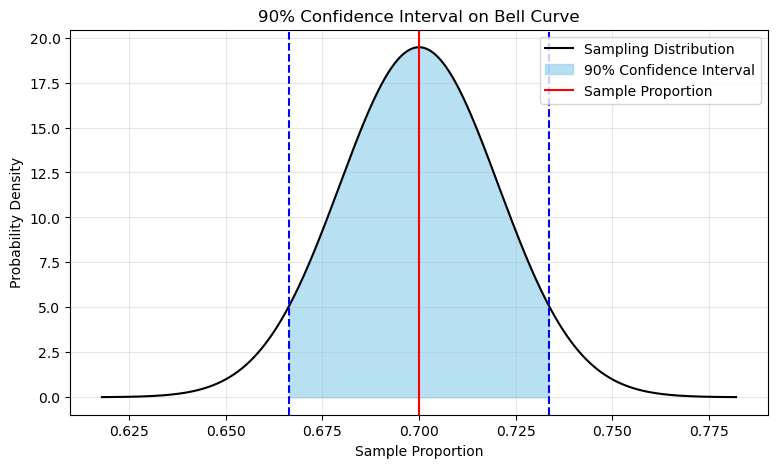

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
n = 500
x = 350
p_hat = x / n
confidence_level = 0.90
z = norm.ppf(1 - (1 - confidence_level) / 2)
se = np.sqrt(p_hat * (1 - p_hat) / n)
ci_lower = p_hat - z * se
ci_upper = p_hat + z * se
x_vals = np.linspace(p_hat - 4*se, p_hat + 4*se, 1000)
y_vals = norm.pdf(x_vals, p_hat, se)
plt.figure(figsize=(9, 5))
plt.plot(x_vals, y_vals, color='black', label='Sampling Distribution')
plt.fill_between(
    x_vals,
    y_vals,
    where=(x_vals >= ci_lower) & (x_vals <= ci_upper),
    color='skyblue',
    alpha=0.6,
    label='90% Confidence Interval'
)
plt.axvline(ci_lower, color='blue', linestyle='--')
plt.axvline(ci_upper, color='blue', linestyle='--')
plt.axvline(p_hat, color='red', linestyle='-', label='Sample Proportion')
plt.xlabel('Sample Proportion')
plt.ylabel('Probability Density')
plt.title('90% Confidence Interval on Bell Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Story 1: Interpretation of the Confidence Interval in Context

#### I asked 500 students about their preference, and 70% of them said they prefer online classes. Because I didn’t ask every student. Therefore, that 70% is just an estimate of the true percentage.The 90% confidence interval gives a range of values that the true percentage is likely to fall within. In this case, the interval says the true proportion of all students who prefer online classes is probably between about 67% and 73%.

#### The “90% confident” means if I repeated this survey many times, each time with a new random sample of 500 students, and built a confidence interval each time, about 90% of those intervals would contain the true proportion of students who prefer online classes, which means it’s very reasonable to believe that roughly two-thirds to three-quarters of students prefer online classes, even though the exact number isn’t known.

## Story 2: Estimating the Average Daily Screen Time of Teenagers

Sample mean: 4.50 hours
95% Confidence Interval: (4.12, 4.88) hours


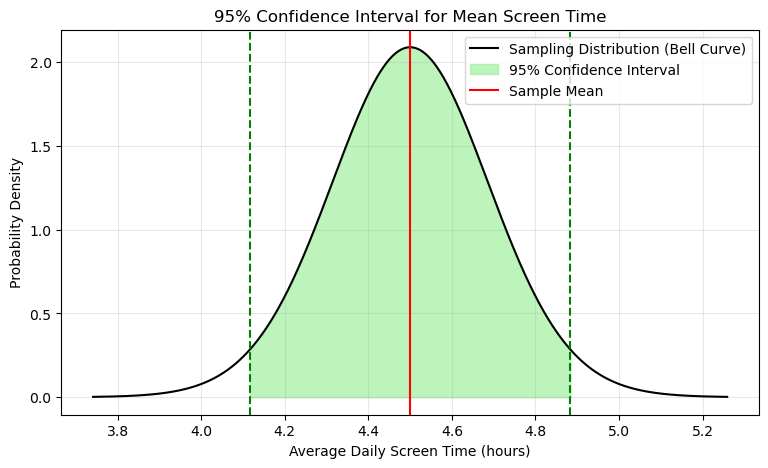

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
n = 40
sample_mean = 4.5        
sample_std = 1.2        
confidence_level = 0.95
df = n - 1
t_critical = t.ppf(1 - (1 - confidence_level) / 2, df)
se = sample_std / np.sqrt(n)
ci_lower = sample_mean - t_critical * se
ci_upper = sample_mean + t_critical * se
print(f"Sample mean: {sample_mean:.2f} hours")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f}) hours")
x_vals = np.linspace(sample_mean - 4*se, sample_mean + 4*se, 1000)
y_vals = t.pdf((x_vals - sample_mean) / se, df) / se
plt.figure(figsize=(9, 5))
plt.plot(x_vals, y_vals, color='black', label='Sampling Distribution (Bell Curve)')
plt.fill_between(
    x_vals,
    y_vals,
    where=(x_vals >= ci_lower) & (x_vals <= ci_upper),
    color='lightgreen',
    alpha=0.6,
    label='95% Confidence Interval'
)
plt.axvline(ci_lower, color='green', linestyle='--')
plt.axvline(ci_upper, color='green', linestyle='--')
plt.axvline(sample_mean, color='red', linestyle='-', label='Sample Mean')
plt.xlabel('Average Daily Screen Time (hours)')
plt.ylabel('Probability Density')
plt.title('95% Confidence Interval for Mean Screen Time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Story 2: Interpretation of the Confidence Interval in Context

#### I surveyed 40 teenagers and found that the average daily screen time in the sample was 4.5 hours. Because this is only a sample and not every teenager, the true average screen time for all teenagers could be a bit higher or lower. The 95% confidence interval gives a range of reasonable values for the true average screen time. Using the data, the interval is approximately 4.1 hours to 4.9 hours. The “95% confident” means is that if I repeated this study many times and calculated a confidence interval each time, about 95% of those intervals would contain the true average screen time.

## Story 3 (Z-Score): Workplace Skills Assessment

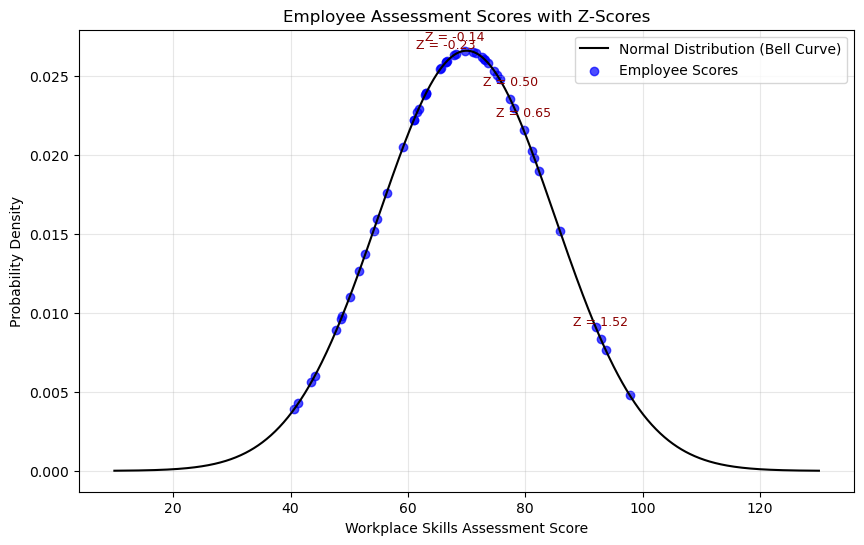

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
np.random.seed(42)
n = 50
mean = 70.0
std_dev = 15.0
scores = np.random.normal(mean, std_dev, n)
z_scores = (scores - mean) / std_dev
x_vals = np.linspace(mean - 4*std_dev, mean + 4*std_dev, 1000)
y_vals = norm.pdf(x_vals, mean, std_dev)
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, color='black', label='Normal Distribution (Bell Curve)')
plt.scatter(scores, norm.pdf(scores, mean, std_dev),
            color='blue', alpha=0.7, label='Employee Scores')
for i in range(5):
    plt.annotate(
        f"Z = {z_scores[i]:.2f}",
        (scores[i], norm.pdf(scores[i], mean, std_dev)),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=9,
        color='darkred'
    )
plt.xlabel('Workplace Skills Assessment Score')
plt.ylabel('Probability Density')
plt.title('Employee Assessment Scores with Z-Scores')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Story 3(Z-Score): Interpretation

### I started by simulating assessment scores for 50 employees, assuming the scores follow a normal distribution with an average score of 70, and a standard deviation of 15, which describes how spread out the scores are. Each dot on the plot represents one employee’s score, placed on top of the curve that shows how scores are expected to be distributed overall. Next, I calculated a Z-score for each employee. A Z-score tells us how far a score is from the average, and whether it is above or below the mean, measured in standard deviations. In my learning of the Z Score, the following examples helped me retain and understand the meaning: A Z-score of 0 means the score is exactly average, A Z-score of +1 means the score is one standard deviation above average, A Z-score of –1 means the score is one standard deviation below average. As instructed, the plot highlights and labels the Z-scores for the first five employees, showing how their individual performance compares to the overall group.In simple terms, this visualization helps us understand where each employee stands relative to others and how typical or unusual their scores are within the organization.

## Story 4 (T-Score): Student's Performance

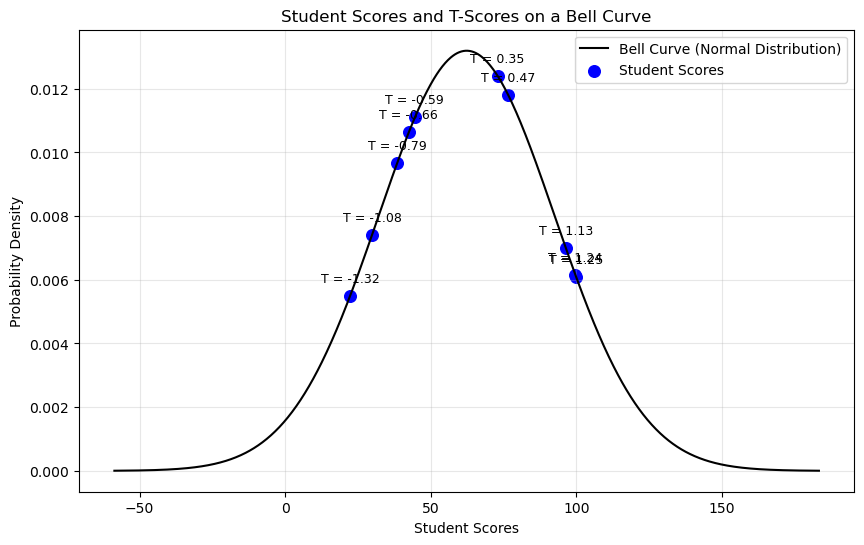

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
np.random.seed(24)
scores = np.random.uniform(10, 100, 10)
mean = np.mean(scores)
std_dev = np.std(scores, ddof=1)
t_scores = (scores - mean) / std_dev
x_vals = np.linspace(mean - 4*std_dev, mean + 4*std_dev, 1000)
y_vals = norm.pdf(x_vals, mean, std_dev)
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, color='black', label='Bell Curve (Normal Distribution)')
plt.scatter(scores, norm.pdf(scores, mean, std_dev),
            color='blue', s=70, label='Student Scores')
for i in range(len(scores)):
    plt.annotate(
        f"T = {t_scores[i]:.2f}",
        (scores[i], norm.pdf(scores[i], mean, std_dev)),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=9
    )
plt.xlabel('Student Scores')
plt.ylabel('Probability Density')
plt.title('Student Scores and T-Scores on a Bell Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Story 4 (T-Score): Interpretation

### I generated 10 random student scores between 10 and 100. These represent raw test scores for a small group of students.Then, I calculated the sample mean and the sample standard deviation, which tells us how spread out the scores are. Using these two values, I computed a T-score for each student, which explains how far a student’s score is from the class average, and whether it is above or below the mean, measured in standard deviations. Overall, this visualization helps us compare students by showing how typical or unusual each score is relative to the rest of the class.

## Story 5: Estimating the Average Age of Employees in a Corporation Using Stratified Sampling

Estimated Mean Age: 38.00 years
95% Confidence Interval: (37.34, 38.66) years


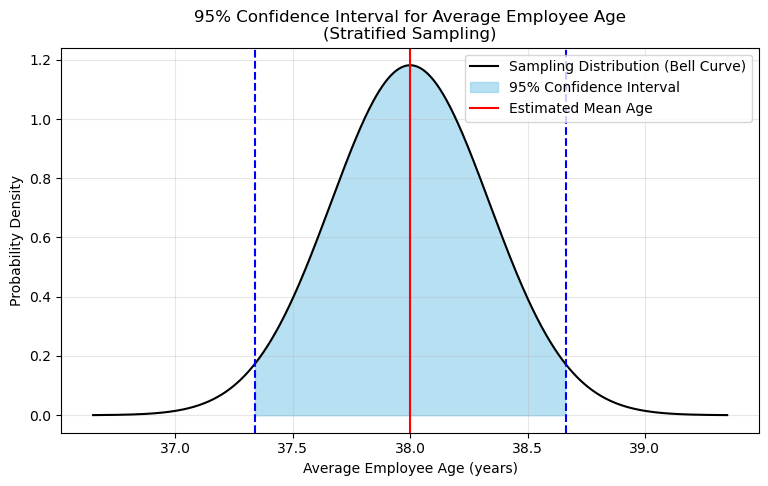

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
N_total = 50000
N_young = 20000
N_middle = 20000
N_older = 10000
w_young = N_young / N_total
w_middle = N_middle / N_total
w_older = N_older / N_total
mean_young = 25
mean_middle = 40
mean_older = 60
sd_young = 5
sd_middle = 6
sd_older = 7
n_total = 300
n_young = int(n_total * w_young)
n_middle = int(n_total * w_middle)
n_older = n_total - n_young - n_middle
overall_mean = (
    w_young * mean_young +
    w_middle * mean_middle +
    w_older * mean_older
)
se = np.sqrt(
    (w_young**2 * sd_young**2 / n_young) +
    (w_middle**2 * sd_middle**2 / n_middle) +
    (w_older**2 * sd_older**2 / n_older)
)
z = norm.ppf(0.975)
ci_lower = overall_mean - z * se
ci_upper = overall_mean + z * se
print(f"Estimated Mean Age: {overall_mean:.2f} years")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f}) years")
x_vals = np.linspace(overall_mean - 4*se, overall_mean + 4*se, 1000)
y_vals = norm.pdf(x_vals, overall_mean, se)
plt.figure(figsize=(9, 5))
plt.plot(x_vals, y_vals, color='black', label='Sampling Distribution (Bell Curve)')
plt.fill_between(
    x_vals, y_vals,
    where=(x_vals >= ci_lower) & (x_vals <= ci_upper),
    color='skyblue',
    alpha=0.6,
    label='95% Confidence Interval'
)
plt.axvline(ci_lower, color='blue', linestyle='--')
plt.axvline(ci_upper, color='blue', linestyle='--')
plt.axvline(overall_mean, color='red', label='Estimated Mean Age')
plt.xlabel('Average Employee Age (years)')
plt.ylabel('Probability Density')
plt.title('95% Confidence Interval for Average Employee Age\n(Stratified Sampling)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Story 5: Interpretation: 

#### Using stratified sampling for 50,000 employees. I grouped them into age categories: young, middle-aged, and old. Each age group has a known population size, and a known standard deviation, which tells me how spread out ages are within that group. By combining the average ages from each group using their population proportions, we get an overall estimated average age for the company. The 95% confidence interval gives a range of reasonable values for the true average employee age, which explains the stratified sampling process many times, about 95% of the confidence intervals would contain the true average age of all employees.The bell curve in the plot represents how the estimated average age would vary across repeated samples. The red line shows the estimated average age. The shaded region shows the 95% confidence interval. I learned the age of employees is very likely to fall within the shaded range.

## Story 6: Estimating the Proportion of Residents Who Own a Car in a City Using Stratified Sampling

Minimum sample sizes by stratum:
Urban: 201
Suburban: 93
Rural: 41
Total minimum sample size needed: 334

Estimated overall car ownership proportion: 0.635
95% Confidence Interval: (0.583, 0.687)


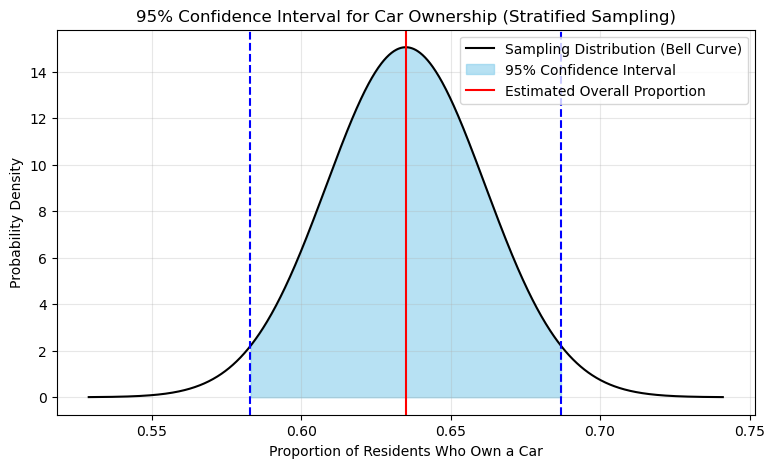

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
N_total = 100000
N_urban = 50000
N_suburban = 30000
N_rural = 20000
w_urban = N_urban / N_total
w_suburban = N_suburban / N_total
w_rural = N_rural / N_total
pU = 0.75
pS = 0.60
pR = 0.40
E = 0.03
confidence = 0.95
z = norm.ppf(1 - (1 - confidence)/2)
n_urban = (w_urban**2 * pU*(1-pU)) / (E**2 / z**2)
n_suburban = (w_suburban**2 * pS*(1-pS)) / (E**2 / z**2)
n_rural = (w_rural**2 * pR*(1-pR)) / (E**2 / z**2)
n_total = n_urban + n_suburban + n_rural
print(f"Minimum sample sizes by stratum:")
print(f"Urban: {np.ceil(n_urban):.0f}")
print(f"Suburban: {np.ceil(n_suburban):.0f}")
print(f"Rural: {np.ceil(n_rural):.0f}")
print(f"Total minimum sample size needed: {np.ceil(n_total):.0f}")
p_hat = w_urban*pU + w_suburban*pS + w_rural*pR
se = np.sqrt(
    (w_urban**2 * pU*(1-pU)/n_urban) +
    (w_suburban**2 * pS*(1-pS)/n_suburban) +
    (w_rural**2 * pR*(1-pR)/n_rural)
)
ci_lower = p_hat - z*se
ci_upper = p_hat + z*se
print(f"\nEstimated overall car ownership proportion: {p_hat:.3f}")
print(f"95% Confidence Interval: ({ci_lower:.3f}, {ci_upper:.3f})")
x_vals = np.linspace(p_hat - 4*se, p_hat + 4*se, 1000)
y_vals = norm.pdf(x_vals, p_hat, se)
plt.figure(figsize=(9,5))
plt.plot(x_vals, y_vals, color='black', label='Sampling Distribution (Bell Curve)')
plt.fill_between(x_vals, y_vals, where=(x_vals >= ci_lower) & (x_vals <= ci_upper),
                 color='skyblue', alpha=0.6, label='95% Confidence Interval')
plt.axvline(p_hat, color='red', linestyle='-', label='Estimated Overall Proportion')
plt.axvline(ci_lower, color='blue', linestyle='--')
plt.axvline(ci_upper, color='blue', linestyle='--')
plt.xlabel('Proportion of Residents Who Own a Car')
plt.ylabel('Probability Density')
plt.title('95% Confidence Interval for Car Ownership (Stratified Sampling)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Story 6: Interpretation

#### I used stratified sampling, dividing the population into urban, suburban, and rural areas, and then ensuring that each type of neighborhood is properly represented in the sample. Based on previous studies, I know roughly how common car ownership is in each neighborhood, which allows me to estimate how many people I need to survey from each area in order to achieve a desired level of precision. Using these estimates, I calculated the minimum number of residents to survey from each neighborhood so that the overall estimate of car ownership has a margin of error no larger than three percent at a 95 percent confidence level. By combining the data from all three neighborhoods and weighting each by the size of its population, it computes an overall estimated proportion of residents who own a car. The 95 percent confidence interval around this estimate provides a range in which the true proportion of car owners in the city is likely to fall. Although the exact proportion is unknown, the city can be reasonably confident that the true value lies within the shaded range. In this way, stratified sampling and careful calculation of the confidence interval gave me a reliable understanding of car ownership across the entire population while accounting for differences between neighborhoods.